# **Part A: Data Loading and Preparation**


In [24]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
learn_rate= 0.001
batch_size = 64
weightdecay = 0.0001
epochs = 10

# Colab: T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Must before the Datasets-Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(  # Normalization
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Loading train/test
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Randomly split into two equal halves
val_size = len(test_dataset) // 2
test_size = len(test_dataset) - val_size
val_dataset, test_dataset = random_split(
    test_dataset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(55) # As you wish
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # For training sets it is necessary
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

Using device: cuda


# **Part B: MLP Implementation and Training**

In [25]:
# Model Architecture
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
        # a: 1024 + ReLU + Dropout(p=0.5)
        nn.Linear(3072, 1024),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        # b: 512 + ReLU + Dropout(p=0.5)
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        # c: 10 CIFAR-10 classes
        nn.Linear(512, 10)

    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.layers(x)
    return logits

# Print
mlp_model = MLP().to(device)
print(mlp_model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [26]:
# Training and Evaluation

# Single epoch training loop
def train_loop(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  model.train()  # Important
  train_loss = 0.0
  correct = 0  # Recording

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)  # Change device

    # Prediction and loss
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # Each record
    train_loss += loss.item() * X.size(0)
    correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    if batch % 100 == 0:
      current = batch * len(X)
      print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

  # Sum and Computation
  avg_loss = train_loss / size
  accuracy = correct / size
  return avg_loss, accuracy

# Single epoch test loop
def test_loop(dataloader, model, loss_fn, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()  # Important
  test_loss = 0.0
  correct = 0  # Recording

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item() * X.size(0)
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  # Sum and Computation
  avg_loss = test_loss / num_batches
  accuracy = correct / size
  print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_loss:>8f} \n")
  return avg_loss, accuracy

In [27]:
# Hyperparameters
loss_fn = nn.CrossEntropyLoss()  # the Cross-Entropy Loss function
mlp_optimizer = optim.Adam(
    mlp_model.parameters(),
    lr= learn_rate,
    weight_decay= weightdecay
)

print(loss_fn, mlp_optimizer)

CrossEntropyLoss() Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [30]:
# Process and recording


# Results we need
mlp_train_losses = []
mlp_train_accs = []
mlp_val_losses = []
mlp_val_accs = []

# Process
for t in range(epochs):
  print(f"Epoch {t+1}/{epochs}\n-------------------------------")
  train_loss, train_acc = train_loop(train_loader, mlp_model, loss_fn, mlp_optimizer, device)
  val_loss, val_acc = test_loop(val_loader, mlp_model, loss_fn, device)

  # Save results
  mlp_train_losses.append(train_loss)
  mlp_train_accs.append(train_acc)
  mlp_val_losses.append(val_loss)
  mlp_val_accs.append(val_acc)

print("Done!")

# Final evaluation
print("\n\nMLP Final Test Set Evaluation:")
mlp_test_loss, mlp_test_acc = test_loop(test_loader, mlp_model, loss_fn, device)
print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")

Epoch 1/10
-------------------------------
loss: 1.649598  [    0/50000]
loss: 1.724971  [ 6400/50000]
loss: 1.549089  [12800/50000]
loss: 1.717371  [19200/50000]
loss: 1.805789  [25600/50000]
loss: 1.702312  [32000/50000]
loss: 1.758085  [38400/50000]
loss: 1.693040  [44800/50000]
Test Error: 
 Accuracy: 40.2%, Avg loss: 107.329792 

Epoch 2/10
-------------------------------
loss: 1.615240  [    0/50000]
loss: 1.778101  [ 6400/50000]
loss: 1.734679  [12800/50000]
loss: 1.505708  [19200/50000]
loss: 1.582328  [25600/50000]
loss: 1.710865  [32000/50000]
loss: 1.814075  [38400/50000]
loss: 1.876873  [44800/50000]
Test Error: 
 Accuracy: 40.0%, Avg loss: 104.340166 

Epoch 3/10
-------------------------------
loss: 1.718812  [    0/50000]
loss: 1.840527  [ 6400/50000]
loss: 1.859756  [12800/50000]
loss: 1.952887  [19200/50000]
loss: 1.737046  [25600/50000]
loss: 1.777183  [32000/50000]
loss: 1.831111  [38400/50000]
loss: 1.740088  [44800/50000]
Test Error: 
 Accuracy: 39.2%, Avg loss: 10

# **Part C: CNN Implementation and Training**

In [31]:
# Model Architecture
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    # [Block 1] as required
    self.block1 = nn.Sequential(
    # Convolution layer:
      nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
      # Activation
      nn.ReLU(),
      # max-pooling layer
      nn.MaxPool2d(kernel_size=3, stride=2)# Get [32, 15, 15]
    )

    # [Block 2] as required
    self.block2 = nn.Sequential(
    # Convolution layer:
      nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
      # Activation
      nn.ReLU(),
      # max-pooling layer
      nn.MaxPool2d(kernel_size=2, stride=2)# Get [64, 7, 7]
    )

    # [Classifier Head] as required
    self.classifier = nn.Sequential(
      nn.Flatten(),
      # Fully-connected layer
      nn.Linear(64 * 7 * 7, 512),# As mentioned
      nn.ReLU(),
      nn.Dropout(p=0.5),
      nn.Linear(512, 10)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    logits = self.classifier(x)
    return logits

# Print
cnn_model = CNN().to(device)
print(cnn_model)

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [32]:
# Process and recording
# Loss_fn and Optimizer are the same
cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr= learn_rate,
    weight_decay= weightdecay
)
# Results we need
cnn_train_losses = []
cnn_train_accs = []
cnn_val_losses = []
cnn_val_accs = []

for t in range(epochs):
  print(f"Epoch {t+1}/{epochs}\n-------------------------------")
  train_loss, train_acc = train_loop(train_loader, cnn_model, loss_fn, cnn_optimizer, device)
  val_loss, val_acc = test_loop(val_loader, cnn_model, loss_fn, device)

  cnn_train_losses.append(train_loss)
  cnn_train_accs.append(train_acc)
  cnn_val_losses.append(val_loss)
  cnn_val_accs.append(val_acc)

print("CNN Training Done!")

# Final evaluation
print("\n\nCNN Final Test Set Evaluation:")
cnn_test_loss, cnn_test_acc = test_loop(test_loader, cnn_model, loss_fn, device)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

Epoch 1/10
-------------------------------
loss: 2.303932  [    0/50000]
loss: 1.621134  [ 6400/50000]
loss: 1.500784  [12800/50000]
loss: 1.556965  [19200/50000]
loss: 1.226122  [25600/50000]
loss: 1.375608  [32000/50000]
loss: 1.351519  [38400/50000]
loss: 1.252341  [44800/50000]
Test Error: 
 Accuracy: 62.9%, Avg loss: 67.544172 

Epoch 2/10
-------------------------------
loss: 1.174027  [    0/50000]
loss: 1.043513  [ 6400/50000]
loss: 0.931960  [12800/50000]
loss: 0.881517  [19200/50000]
loss: 1.043881  [25600/50000]
loss: 1.144818  [32000/50000]
loss: 0.829437  [38400/50000]
loss: 0.961196  [44800/50000]
Test Error: 
 Accuracy: 68.5%, Avg loss: 56.955943 

Epoch 3/10
-------------------------------
loss: 0.762860  [    0/50000]
loss: 0.856299  [ 6400/50000]
loss: 1.009237  [12800/50000]
loss: 1.073993  [19200/50000]
loss: 0.615452  [25600/50000]
loss: 0.698446  [32000/50000]
loss: 1.020795  [38400/50000]
loss: 0.674198  [44800/50000]
Test Error: 
 Accuracy: 72.2%, Avg loss: 50.2

# **Part D: Analysis and Discussion**

### 1. Performance Comparison:

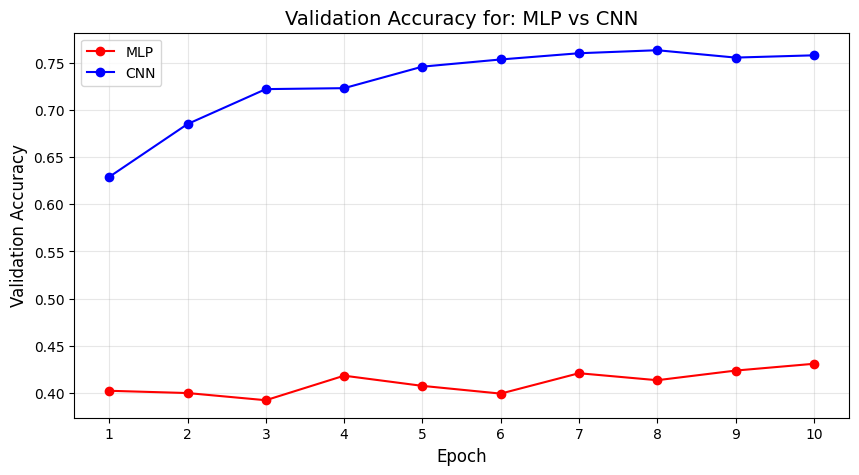

In [33]:
# Plot generation
import matplotlib.pyplot as plt
import pandas as pd

# Displaying the validation accuracy curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), mlp_val_accs, label='MLP', color='red', marker='o')
plt.plot(range(1, 11), cnn_val_accs, label='CNN', color='blue', marker='o')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Validation Accuracy for: MLP vs CNN', fontsize=14)
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

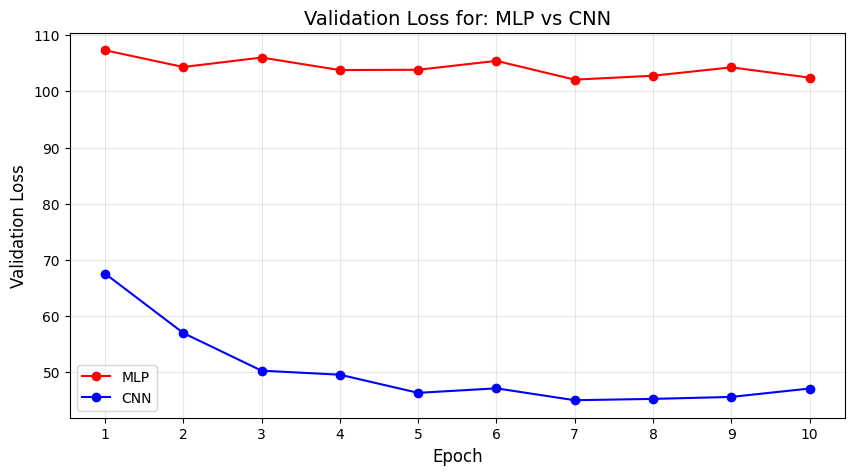

In [34]:
# Displaying the validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), mlp_val_losses, label='MLP', color='red', marker='o')
plt.plot(range(1, 11), cnn_val_losses, label='CNN', color='blue', marker='o')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Validation Loss for: MLP vs CNN', fontsize=14)
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
# The final test accuracies in a table
test_results = pd.DataFrame({
  'Model': ['MLP', 'CNN'],
  'Final Test Accuracy': [f'{mlp_test_acc:.4f}', f'{cnn_test_acc:.4f}']
})
print(test_results)

  Model Final Test Accuracy
0   MLP              0.4204
1   CNN              0.7632


## 2. Model Complexity:

In [36]:
# Counting function implementation
def count_trainable_parameters(model):

  return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [38]:
# For former MLP and CNN

mlp_params = count_trainable_parameters(mlp_model)
cnn_params = count_trainable_parameters(cnn_model)

# The result in a table
param_results = pd.DataFrame({
    'Model': ['MLP', 'CNN'],
    'Trainable Parameters': [f'{mlp_params:,}', f'{cnn_params:,}']
})
print(param_results)

  Model Trainable Parameters
0   MLP            3,676,682
1   CNN            1,630,666


## 3. Discussion:

CNN outperform MLP significantly in image classification, with the core reason being their stronger structural adaptability to image data:

1. MLPs lose pixel spatial information when flattening images into 1D vectors; while CNNs focus on local regions via convolutional layers to fit image local correlation, and multi-layer convolutions further strengthen this advantage.
2. The number of parameters in MLP's fully connected layers surges with input dimensions, leading to heavy computation and easy overfitting; CNNs achieve parameter sharing with convolution kernels, greatly improving generalization ability.
3. Unlike MLPs, CNNs include pooling layers, which reduce feature map size and enhance tolerance to minor changes and noise in input images.